<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/PL8_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prelab 8.3 Classifying Air-tight Vacuum and Air-leak Vacuum Data using Autoencoders for Anomaly Detection: Y and Z-axis

In [24]:
# Let's check the installed pytorch version
import torch

print('Torch Version is', torch.__version__)

Torch Version is 2.10.0+cu128


In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [26]:
# Copying raw data from github dataset file
url = 'https://raw.githubusercontent.com/purduelamm/purdue_me597_iiot/main/lab/lab8/Prelab8_data.csv'

# df is the variable where the data is stored
df = pd.read_csv(url)

# Data selection
AXIS = 'Yacc array [m/s2]'  # Pick and write the axis you want to work

# Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat([df['Condition'], df[AXIS].str.split(' ', expand=True).astype(float)], axis=1)
ds = df_new.copy()

# Converting the Classifier into binary values
ds.loc[df['Condition'] == 'Vacuuming', 'Status'] = 1
ds.loc[df['Condition'] == 'Air_leakage', 'Status'] = 0
ds.drop('Condition', axis=1, inplace=True)

# Data transformation
raw_data = ds.values

# The last element contains the labels
labels = raw_data[:, -1]

# The other data points are the vacuum accelerometer data
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)

# Normalizing the values of the dataset
min_val = train_data.min()
max_val = train_data.max()
eps = 1e-8

train_data = (train_data - min_val) / (max_val - min_val + eps)
test_data = (test_data - min_val) / (max_val - min_val + eps)

train_data = torch.tensor(train_data, dtype=torch.float32)
test_data = torch.tensor(test_data, dtype=torch.float32)

train_labels = torch.tensor(train_labels, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.float32)

# Splitting the dataset based on classification: train_labels: Vacuuming, ~train_labels: Air Leakage
train_labels = train_labels.bool()
test_labels = test_labels.bool()

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

portion_of_anomaly_in_training = 0.1  # 10% of training data will be anomalies
end_size = int(len(normal_train_data) / (10 - portion_of_anomaly_in_training * 10))

combined_train_data = torch.cat([normal_train_data, anomalous_test_data[:end_size]], dim=0)
combined_train_data.shape

torch.Size([536, 1000])

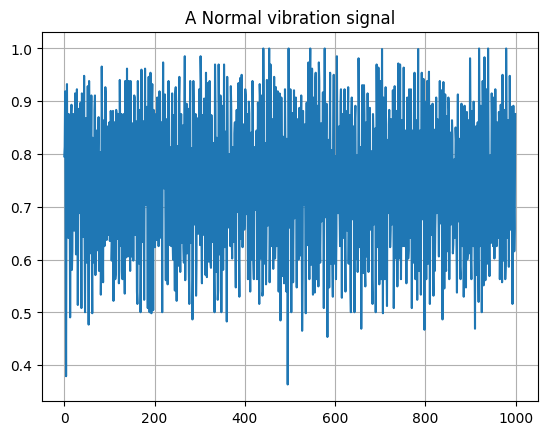

In [27]:
#Plotting sample of normal data
plt.grid()
plt.plot(np.arange(1000), normal_train_data[0])
plt.title("A Normal vibration signal")
plt.show()

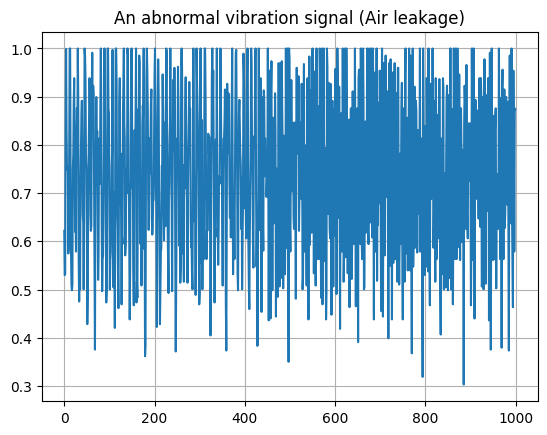

In [28]:
#Plotting sample of anomalous data
plt.grid()
plt.plot(np.arange(1000), anomalous_train_data[0])
plt.title("An abnormal vibration signal (Air leakage)")
plt.show()

In [29]:
# Creating the artificial neural network using Autoencoder
EMBEDDING_SIZE = 64  # Define how many neurons in the inner layer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class AnomalyDetector(nn.Module):
    def __init__(self):
        super(AnomalyDetector, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(1000, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, EMBEDDING_SIZE),
            nn.ReLU()
        )  # Smallest Layer Defined Here

        self.decoder = nn.Sequential(
            nn.Linear(EMBEDDING_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 1000),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = AnomalyDetector().to(device)
print("Chosen Embedding Size: ", EMBEDDING_SIZE)

criterion = nn.L1Loss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# Training the model.
train_dataset = TensorDataset(normal_train_data, normal_train_data)
train_loader = DataLoader(train_dataset, batch_size=200, shuffle=True)

history = {
    "loss": [],
    "val_loss": []
}

for epoch in range(200):
    autoencoder.train()
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = autoencoder(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    autoencoder.eval()
    with torch.no_grad():
        val_input = test_data.to(device)
        val_output = autoencoder(val_input)
        val_loss = criterion(val_output, val_input).item()

    history["loss"].append(epoch_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch [{epoch+1}/200] - loss: {epoch_loss:.6f} - val_loss: {val_loss:.6f}")

Chosen Embedding Size:  64
Epoch [1/200] - loss: 0.243003 - val_loss: 0.243173
Epoch [2/200] - loss: 0.240615 - val_loss: 0.240420
Epoch [3/200] - loss: 0.237128 - val_loss: 0.235500
Epoch [4/200] - loss: 0.230459 - val_loss: 0.227021
Epoch [5/200] - loss: 0.219712 - val_loss: 0.215615
Epoch [6/200] - loss: 0.205949 - val_loss: 0.203997
Epoch [7/200] - loss: 0.193079 - val_loss: 0.194034
Epoch [8/200] - loss: 0.181603 - val_loss: 0.182095
Epoch [9/200] - loss: 0.168244 - val_loss: 0.169926
Epoch [10/200] - loss: 0.155605 - val_loss: 0.159969
Epoch [11/200] - loss: 0.144937 - val_loss: 0.150832
Epoch [12/200] - loss: 0.135016 - val_loss: 0.143252
Epoch [13/200] - loss: 0.127075 - val_loss: 0.137263
Epoch [14/200] - loss: 0.120520 - val_loss: 0.132188
Epoch [15/200] - loss: 0.115212 - val_loss: 0.128459
Epoch [16/200] - loss: 0.111121 - val_loss: 0.125353
Epoch [17/200] - loss: 0.107784 - val_loss: 0.123126
Epoch [18/200] - loss: 0.105302 - val_loss: 0.121322
Epoch [19/200] - loss: 0.103

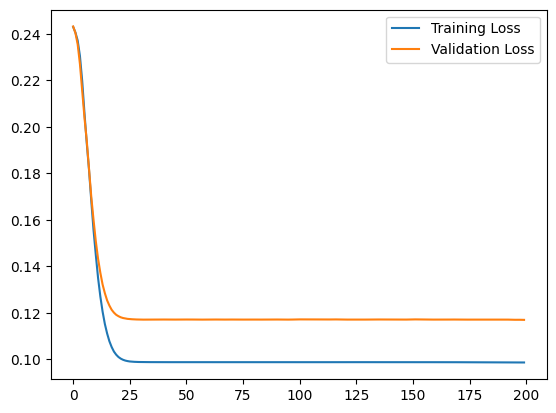

In [30]:
# Plotting the evolution of training and validation loss
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()

How are the loss functions looking? Is there a need to adjust the EMBEDDING SIZE or the epochs in order to minimize it more?

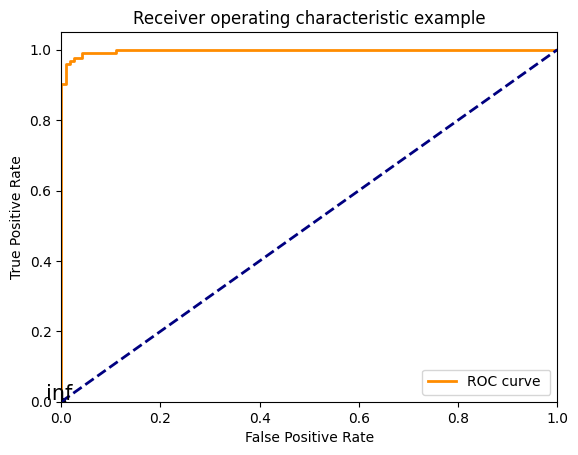

In [31]:
# Plotting True positive and false positive rate assessment
autoencoder.eval()

with torch.no_grad():
    reconstructions = autoencoder(test_data.to(device))
    loss = torch.mean(torch.abs(reconstructions - test_data.to(device)), dim=1)

loss = loss.cpu().numpy()
fpr = []
tpr = []

# the test labels are flipped to match how the roc_curve function expects them.
flipped_labels = 1 - test_labels.cpu().numpy()

fpr, tpr, thresholds = roc_curve(flipped_labels, loss)

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# plot some thresholds
thresholds_every = 20
thresholdsLength = len(thresholds)
colorMap = plt.get_cmap('jet', thresholdsLength)

for i in range(0, thresholdsLength, thresholds_every):
    threshold_value_with_max_four_decimals = str(thresholds[i])[:5]
    plt.scatter(fpr[i], tpr[i], c='black')
    plt.text(fpr[i] - 0.03, tpr[i] + 0.005,
             threshold_value_with_max_four_decimals,
             fontdict={'size': 15})

plt.show()

In [32]:
from sklearn.metrics import auc
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.9975679243971927


In [33]:
threshold = 0.12  # Assign a value labeled in black in the ROC graph

def predict(model, data, threshold):
    model.eval()

    with torch.no_grad():
        data = data.to(device)
        reconstructions = model(data)
        loss = torch.mean(torch.abs(reconstructions - data), dim=1)
        predictions = loss < threshold

    return predictions.cpu().numpy(), loss.cpu().numpy()

def print_stats(predictions, labels):
    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()

    print("Accuracy = {}".format(accuracy_score(labels, predictions)))
    print("Precision = {}".format(precision_score(labels, predictions)))
    print("Recall = {}".format(recall_score(labels, predictions)))

preds, scores = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.9416666666666667
Precision = 1.0
Recall = 0.8803418803418803


### Task 3.1
How can you compare the models using data from the X-axis and Y-axis data? which one does a better job classifying? Explain your reasoning.



---

Write down your answer to Task 3.1 here.

---


##Working in the Z-axis

Recycle the code from the previous two dimensions, to build a model using the data from the Z-axis.

In [34]:
#Your code here




#

### Task 3.2
Which model (X, Y, or Z) would you choose to classify normal and abnormal readings for the vacuum problem? Explain your reasoning.



---

Write down your answer to Task 3.2 here.

---


### Task 3.3
What other data transformations/extractions would you consider to build a model to classify normal and abnormal data on the vacuum problem?



---

Write down your answer to Task 3.3 here.

---


<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)